
--- Sample 'salary.csv' with 1000 entries generated successfully ---
First 5 rows of generated data:
  gender  salary
0    men  143903
1    men  109535
2    men  105454
3    men   83468
4    men  125975

Last 5 rows of generated data:
    gender  salary
995  women   98451
996  women   90123
997  women   71620
998  women   94073
999  women   91553


C:\Users\Admin\AppData\Local\Temp\ipykernel_14884\3680626380.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(


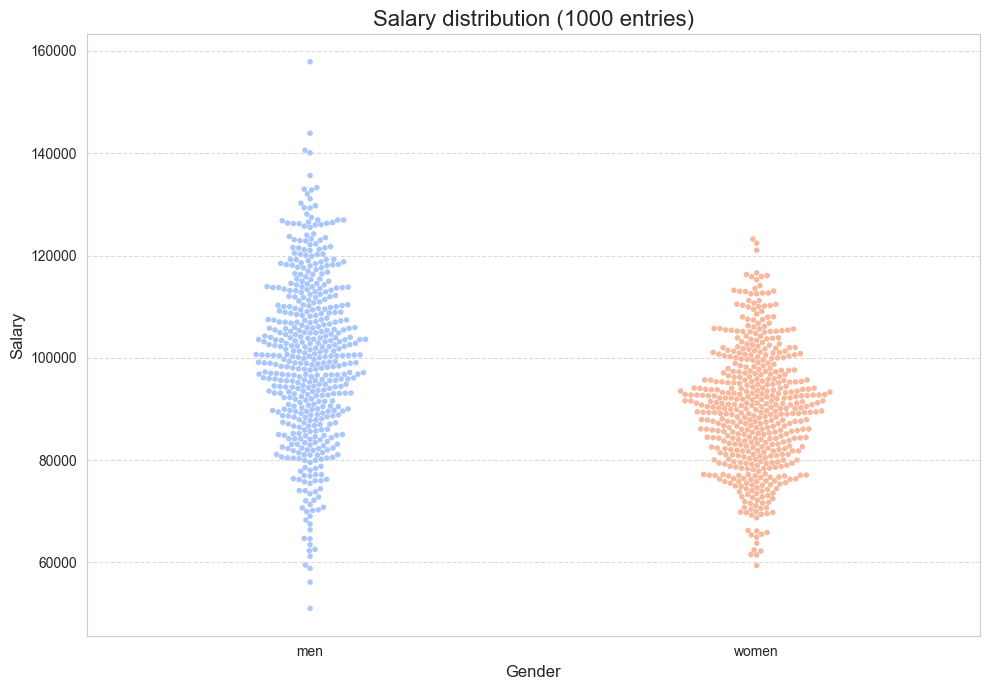

In [3]:
# Nguyễn Hoàng Tùng

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Define the filename for the salary dataset
file_name = "salary.csv"
num_entries_per_gender = 500 # Total entries will be 1000

# 1. Generate sample data for salary.csv with 1000 entries
# Create a DataFrame with 'gender' and 'salary' columns as specified in the task [3]
# We'll create a hypothetical dataset with a mix of salaries for men and women
# using numpy.random.normal to simulate realistic distributions.
data = {
    'gender': (['men'] * num_entries_per_gender) + (['women'] * num_entries_per_gender),
    'salary': np.concatenate([
        # Men's salaries centered around 100,000 with a standard deviation of 15,000
        np.random.normal(100000, 15000, num_entries_per_gender),
        # Women's salaries centered around 90,000 with a standard deviation of 12,000
        np.random.normal(90000, 12000, num_entries_per_gender)
    ]).astype(int) # Convert salaries to integers for realism
}
# Ensure no negative salaries due to normal distribution randomness by setting a floor
data['salary'][data['salary'] < 20000] = 20000

salary_df = pd.DataFrame(data)

# Save the DataFrame to a CSV file
try:
    salary_df.to_csv(file_name, index=False)
    print(f"\n--- Sample '{file_name}' with {len(salary_df)} entries generated successfully ---")
    print("First 5 rows of generated data:")
    print(salary_df.head()) # Display the first few rows of the generated data
    print("\nLast 5 rows of generated data:")
    print(salary_df.tail()) # Display the last few rows of the generated data

    # 2. Load the data and plot the salary distribution using Seaborn's swarmplot
    # The task explicitly refers to page 90 of book 2 for `sns.swarmplot` [1, 2].
    loaded_data = pd.read_csv(file_name)

    # Initialize Seaborn style for better aesthetics, as mentioned in book 2 examples
    sns.set_style("whitegrid") # This specific style is used in the book's example for swarmplot [1]

    # Plotting the swarmplot as demonstrated on page 90 of book 2 [1]
    plt.figure(figsize=(10, 7)) # Adjust figure size for better readability
    sns.swarmplot(
        x="gender",             # Categorical variable for the x-axis ('men', 'women')
        y="salary",             # Quantitative variable for the y-axis (salary values)
        data=loaded_data,       # The DataFrame containing the salary data
        palette="coolwarm",     # A different color palette for variety, if desired
        size=4                  # Adjust marker size for 1000 points
    )

    plt.title("Salary distribution (1000 entries)", fontsize=16) # Set the title for the plot, as shown in book 2 [1]
    plt.xlabel("Gender", fontsize=12)            # Label for the x-axis
    plt.ylabel("Salary", fontsize=12)            # Label for the y-axis
    plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a grid for better readability
    plt.tight_layout() # Adjust layout to prevent labels from overlapping
    plt.show()                      # Display the plot

except IOError as e:
    print(f"Error: Could not save or load the file '{file_name}'. {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")